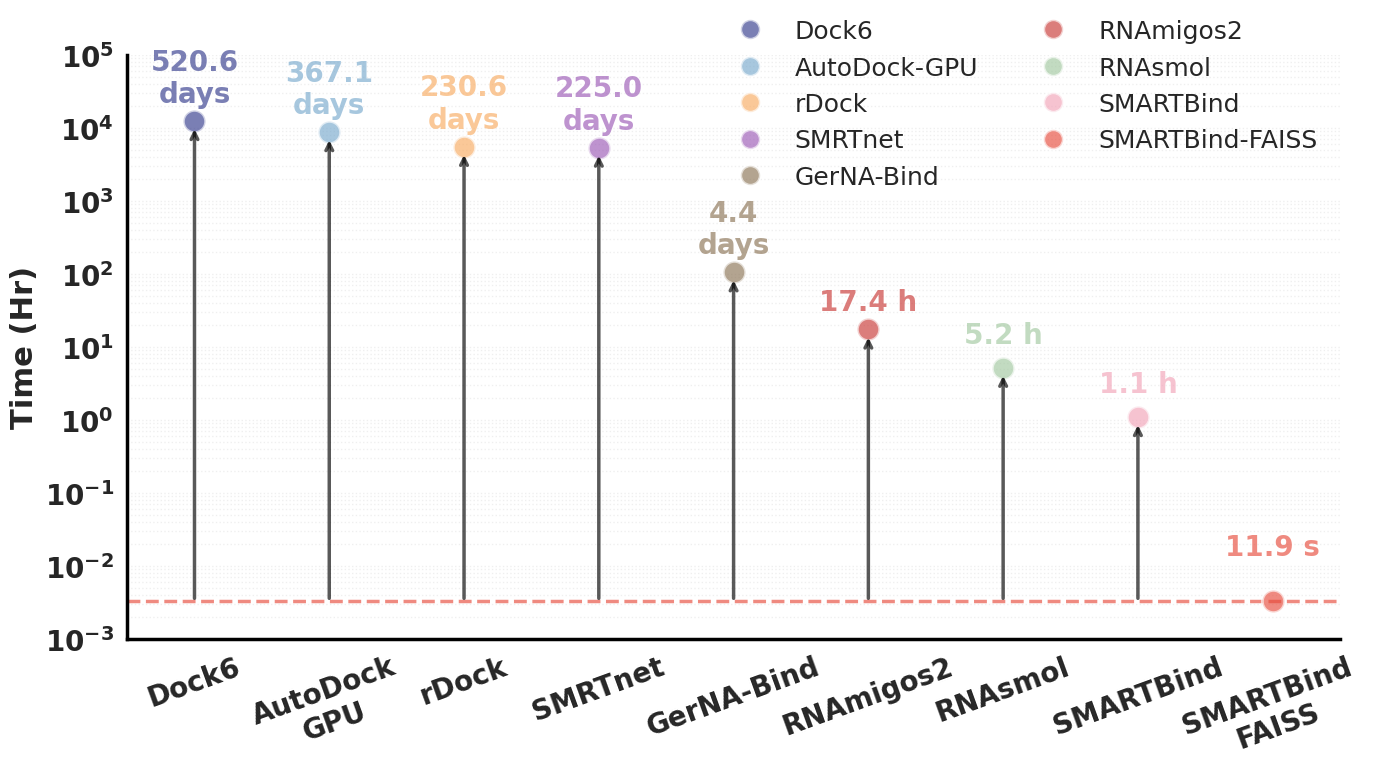

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

methods_orig = ['Dock6', 'rDock', 'AutoDock\nGPU', 'RNAmigos2', 'RNAsmol', 'SMARTBind', 'GerNA-Bind', 'SMRTnet', 'SMARTBind\nFAISS']
methods_legend_orig = ['Dock6', 'rDock', 'AutoDock-GPU', 'RNAmigos2', 'RNAsmol', 'SMARTBind', 'GerNA-Bind', 'SMRTnet', 'SMARTBind-FAISS']
colors_orig = ['#333A8C', '#F8AB61', '#78A9CD', '#C93735', '#A2C8A0', '#F2A3B8', '#8B7355', '#9B59B6', '#E74C3C']
time_means_orig = [12494.8, 5534.7, 8811.1, 17.4, 5.2, 1.1, 105.8, 5400.7, 11.9/3600]

# sort by time_means_orig in descending order
sorted_indices = sorted(range(len(time_means_orig)), key=lambda i: time_means_orig[i], reverse=True)
methods = [methods_orig[i] for i in sorted_indices]
methods_legend = [methods_legend_orig[i] for i in sorted_indices]
colors = [colors_orig[i] for i in sorted_indices]
time_means = [time_means_orig[i] for i in sorted_indices]

reference_time = min(time_means)

x = np.arange(len(methods))

sns.set(style="white")

fig, ax = plt.subplots(figsize=(14, 8))

for xi, mean, color in zip(x, time_means, colors):
    ax.plot(xi, mean, 'o', markersize=16, color=color, markeredgewidth=2, markeredgecolor='white', alpha=0.65)

ax.axhline(y=reference_time, color='#E74C3C', linestyle='--', linewidth=2.5, alpha=0.65, zorder=1)
for i in range(len(methods)):
    if time_means[i] != reference_time:
        start = reference_time
        end = time_means[i] * 0.85

        ax.annotate("",
                    xy=(x[i], end),
                    xytext=(x[i], start),
                    arrowprops=dict(arrowstyle='->', lw=2.5, color='black', alpha=0.65))

for i, (mean, this_method) in enumerate(zip(time_means, methods)):
    if mean >= 24:  
        days = mean / 24
        label = f'{days:.1f}\ndays'
    elif mean >= 1: 
        label = f'{mean:.1f} h'
    else:  
        seconds = mean * 3600
        label = f'{seconds:.1f} s'
    
    if mean < 0.01:
        y_offset = mean * 2.5
    elif mean < 1:
        y_offset = mean * 1.8
    elif mean < 10:
        y_offset = mean * 0.8
    else:
        y_offset = mean * 0.5
    
    ax.text(x[i], mean + y_offset, label, ha='center', va='bottom', 
            fontsize=20, fontweight='bold', color=colors[i], alpha=0.65)

fontsize = 26
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=fontsize-6, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=20, ha='center')
ax.set_ylabel('Time (Hr)', fontsize=fontsize-4, fontweight='bold')
ax.set_yscale('log')
ax.set_ylim(0.001, 100000)
ax.set_xlim(-0.5, len(methods) - 0.5)
plt.yticks(fontsize=fontsize-6, fontweight='bold')

ax.grid(True, which='both', axis='y', linestyle=':', alpha=0.3, zorder=0)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
    spine.set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
custom_lines = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', 
                          markersize=14, markeredgewidth=2, markeredgecolor='white', alpha=0.65) 
                for color in colors]
ax.legend(custom_lines, methods_legend, fontsize=fontsize-8, loc='upper right', 
         bbox_to_anchor=(1.0, 1.1), frameon=False, fancybox=True, shadow=False, ncol=2)

plt.tight_layout()
plt.savefig('figure4d_efficiency.svg', dpi=400, bbox_inches='tight')
plt.savefig('figure4d_efficiency.png', dpi=600, bbox_inches='tight')
plt.show()